# 01 EDA

Exploracion descriptiva inicial sobre una **muestra balanceada de las tablas RAW** `YELLOW_TRIPS_DEV` y `GREEN_TRIPS_DEV`, obtenida directamente desde Snowflake sin descargar el universo completo de viajes a pandas. El objetivo es documentar con evidencia que la futura limpieza y la OBT final salen de observaciones concretas sobre la data original.

## Alcance de esta muestra

- la muestra se toma sobre `RAW` y no sobre `STAGING` ni `OBT`
- cuando `TRIP_TYPE=yellow,green`, el notebook fuerza cobertura pareja por flota para evitar que una tabla domine el EDA
- las columnas temporales como `pickup_hour`, `pickup_dayofweek` y `pickup_month` se derivan solo para analisis descriptivo; no implican que RAW ya sea una tabla lista para modelado

## Que se valida en este notebook

- que la ingesta raw ya esta poblada y utilizable sin descargar la base completa
- que `fare_amount` y `estimated_distance` exponen defectos y outliers relevantes antes de cualquier limpieza
- que `yellow` y `green` pueden analizarse bajo un contrato canonico comun sin perder trazabilidad de origen
- que las columnas de leakage existen en raw y quedan identificadas para excluirlas del contrato final
- que los hallazgos del EDA son suficientes para justificar reglas de `data_cleaning`, `STAGING` y OBT

## Lectura esperada del notebook

1. cobertura de muestra y unificacion canonica de columnas
2. calidad estructural: nulos, rangos imposibles y leakage
3. distribuciones, estacionalidad y outliers que afectan el modelado
4. conclusiones accionables para `02_data_cleaning.ipynb` y para el SQL final de transformacion

## Criterio de exito

Este notebook se considera correcto si demuestra que la muestra de `RAW.YELLOW_TRIPS_DEV` y `RAW.GREEN_TRIPS_DEV`:

- refleja fielmente la estructura original de los viajes
- expone con claridad las columnas que luego deben excluirse por leakage
- mantiene una vista interpretable del target y de `estimated_distance`
- deja identificados los puntos que deben vigilarse antes de construir la OBT final


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / 'src').exists() and (PROJECT_ROOT.parent / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('PROJECT_ROOT =', PROJECT_ROOT)


PROJECT_ROOT = /home/pabseb/DataMining/final-project/price-prediction-ml-end-to-end


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.ingestion import balanced_raw_sample_sql, fetch_sample
from src.features.build_features import DISTANCE_COLUMN, LEAKAGE_COLUMNS, TARGET_COLUMN, add_temporal_features, build_candidate_modeling_frame, normalize_raw_taxi_frame
from src.utils.config import get_settings

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)

settings = get_settings()
sample_limit = 10000

raw_sample = fetch_sample(
    balanced_raw_sample_sql(settings, limit=sample_limit, sample_seed=settings.eda_sample_seed),
    limit=sample_limit,
    settings=settings,
)

sample_df = normalize_raw_taxi_frame(raw_sample)
eda_df = add_temporal_features(sample_df)

candidate_df = build_candidate_modeling_frame(
    raw_sample,
    start_date=settings.data_start_date,
    end_date=settings.data_end_date,
)

assert not raw_sample.empty, 'La muestra raw del EDA esta vacia. Revisa setup/ingest.'
print('trip_types =', settings.trip_type_label)
print('raw sample shape =', raw_sample.shape)
print('raw columns =', raw_sample.columns.tolist())
print('canonical columns =', sample_df.columns.tolist())
print('eda columns =', eda_df.columns.tolist())
print('sample by trip_type =')
print(sample_df['trip_type'].value_counts(dropna=False).sort_index())
print('candidate rows after rules =', len(candidate_df))
eda_df.head()


trip_types = yellow,green
raw sample shape = (10000, 19)
raw columns = ['trip_type', 'vendorid', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'trip_distance', 'ratecodeid', 'pulocationid', 'dolocationid', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']
canonical columns = ['trip_type', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'trip_distance', 'ratecode_id', 'pickup_location_id', 'dropoff_location_id', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee', 'estimated_distance']
eda columns = ['trip_type', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'trip_distance', 'ratecode_id', 'pickup_location_id', 'dropoff_location_id', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount',

,trip_type,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,ratecode_id,pickup_location_id,dropoff_location_id,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,estimated_distance,pickup_hour,pickup_dayofweek,pickup_month,is_weekend,is_rush_hour,is_night,log_estimated_distance,route_id,same_zone
0,green,2,2025-05-29 19:20:50,2025-05-29 19:29:36,1.0,1.27,1.0,75,237,1.0,10.7,2.50,0.5,1.50,0.0,1.0,18.95,2.75,NaN,1.27,19,3,5,0,1,0,0.819780,75_237,0
1,green,2,2025-02-01 07:09:48,2025-02-02 06:19:53,1.0,2.15,1.0,74,236,2.0,12.8,0.00,0.5,0.00,0.0,1.0,14.30,0.00,NaN,2.15,7,5,2,1,1,0,1.147402,74_236,0
2,green,1,2025-03-07 15:24:25,2025-03-07 15:42:50,1.0,2.70,1.0,74,238,1.0,19.1,2.75,1.5,4.65,0.0,1.0,28.00,2.75,NaN,2.70,15,4,3,0,0,0,1.308333,74_238,0
3,yellow,2,2025-05-29 18:50:54,2025-05-29 19:20:46,3.0,7.41,1.0,138,129,1.0,36.6,7.50,0.5,9.12,0.0,1.0,56.47,0.00,1.75,7.41,18,3,5,0,1,0,2.129421,138_129,0
4,yellow,1,2025-03-13 17:12:38,2025-03-13 17:24:41,1.0,1.50,1.0,142,237,1.0,11.4,5.75,0.5,3.75,0.0,1.0,22.40,2.50,0.00,1.50,17,3,3,0,1,0,0.916291,142_237,0


In [3]:
required_cols = [
    'trip_type', 'fare_amount', DISTANCE_COLUMN, 'passenger_count', 'pickup_hour',
    'pickup_dayofweek', 'pickup_month', 'pickup_location_id', 'dropoff_location_id'
]
missing_cols = sorted(set(required_cols).difference(eda_df.columns))
assert not missing_cols, f'Faltan columnas esperadas en el frame de EDA: {missing_cols}'
required_cols


['trip_type',
 'fare_amount',
 'estimated_distance',
 'passenger_count',
 'pickup_hour',
 'pickup_dayofweek',
 'pickup_month',
 'pickup_location_id',
 'dropoff_location_id']

In [4]:
eda_summary = (
    pd.DataFrame({
        'dtype': eda_df.dtypes.astype(str),
        'nulls': eda_df.isna().sum(),
        'null_pct': (eda_df.isna().mean() * 100).round(2),
        'n_unique': eda_df.nunique(dropna=False),
    })
    .sort_values(['null_pct', 'n_unique'], ascending=[False, False])
)
eda_summary


,dtype,nulls,null_pct,n_unique
airport_fee,float64,6083,60.83,4
passenger_count,float64,1392,13.92,10
ratecode_id,float64,1392,13.92,7
congestion_surcharge,float64,1392,13.92,5
payment_type,float64,309,3.09,6
dropoff_datetime,datetime64[ns],0,0.00,9995
pickup_datetime,datetime64[ns],0,0.00,9993
route_id,object,0,0.00,3413
total_amount,float64,0,0.00,2887
trip_distance,float64,0,0.00,1321


In [5]:
numeric_cols = [
    'fare_amount', DISTANCE_COLUMN, 'passenger_count', 'pickup_hour',
    'pickup_dayofweek', 'pickup_month'
]
eda_df[numeric_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T


,count,mean,std,min,1%,5%,50%,95%,99%,max
fare_amount,10000.0,17.878588,16.987461,-119.6,-5.1025,3.9850,13.5,49.2000,75.1000,288.60
estimated_distance,10000.0,3.873869,79.810450,0.0,0.0000,0.1495,1.8,10.6705,18.6802,7974.43
passenger_count,8608.0,1.297514,0.871896,0.0,0.0000,1.0000,1.0,3.0000,6.0000,9.00
pickup_hour,10000.0,14.103400,5.577636,0.0,0.0000,3.0000,15.0,22.0000,23.0000,23.00
pickup_dayofweek,10000.0,2.987000,1.928886,0.0,0.0000,0.0000,3.0,6.0000,6.0000,6.00
pickup_month,10000.0,3.596800,1.689590,1.0,1.0000,1.0000,4.0,6.0000,6.0000,6.00


In [6]:
quality_checks = pd.Series({
    'rows': len(sample_df),
    'target_le_zero': int((sample_df[TARGET_COLUMN] <= 0).sum()),
    f'{DISTANCE_COLUMN}_le_zero': int((sample_df[DISTANCE_COLUMN] <= 0).sum()),
    'passenger_out_of_range': int(((sample_df['passenger_count'] < 1) | (sample_df['passenger_count'] > 6)).sum()),
    'null_pickup_location': int(sample_df['pickup_location_id'].isna().sum()),
    'null_dropoff_location': int(sample_df['dropoff_location_id'].isna().sum()),
    'raw_yellow_rows': int((sample_df['trip_type'] == 'yellow').sum()),
    'raw_green_rows': int((sample_df['trip_type'] == 'green').sum()),
}, name="value")
quality_checks


rows                          10000
target_le_zero                  306
estimated_distance_le_zero      395
passenger_out_of_range          103
null_pickup_location              0
null_dropoff_location             0
raw_yellow_rows                5000
raw_green_rows                 5000
Name: value, dtype: int64

In [7]:
forbidden_found = sorted(set(raw_sample.columns).intersection(LEAKAGE_COLUMNS))
print('Leakage columns found in sampled RAW:', forbidden_found)


Leakage columns found in sampled RAW: ['airport_fee', 'congestion_surcharge', 'dropoff_datetime', 'extra', 'improvement_surcharge', 'mta_tax', 'payment_type', 'tip_amount', 'tolls_amount', 'total_amount']


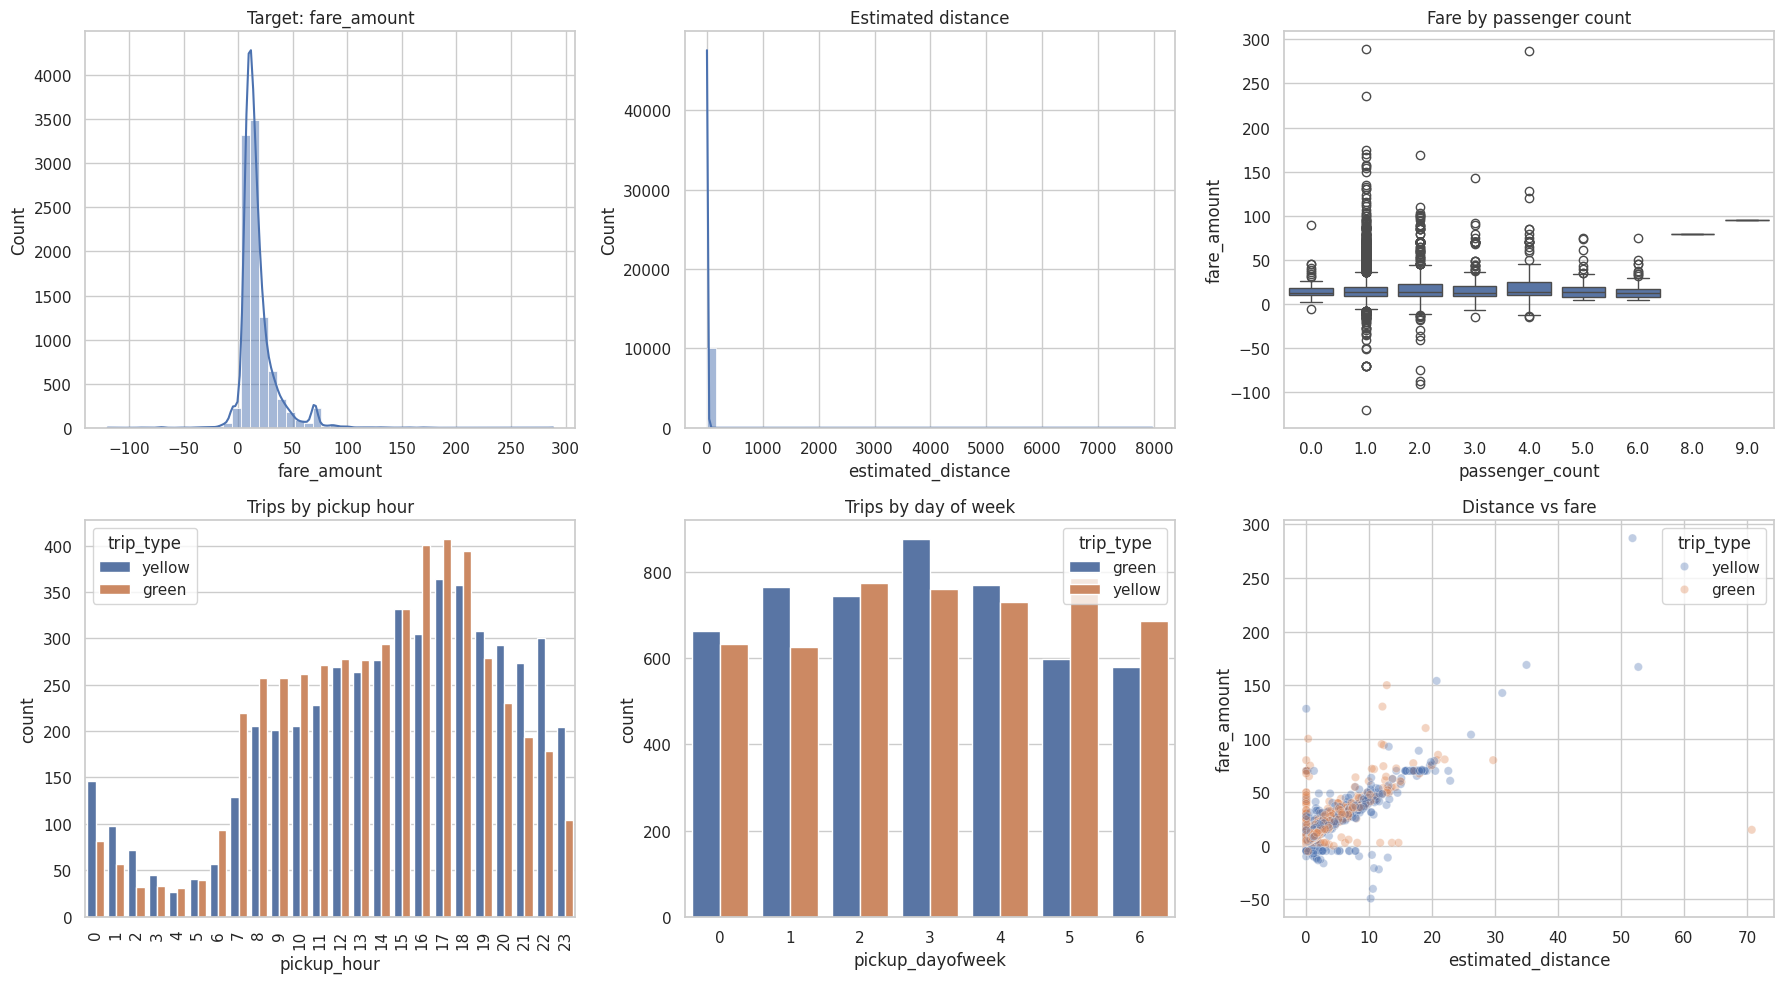

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
sns.histplot(eda_df['fare_amount'], bins=50, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Target: fare_amount')
sns.histplot(eda_df[DISTANCE_COLUMN], bins=50, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Estimated distance')
sns.boxplot(data=eda_df, x='passenger_count', y='fare_amount', ax=axes[0, 2])
axes[0, 2].set_title('Fare by passenger count')
sns.countplot(data=eda_df, x='pickup_hour', hue='trip_type', ax=axes[1, 0])
axes[1, 0].set_title('Trips by pickup hour')
axes[1, 0].tick_params(axis='x', rotation=90)
sns.countplot(data=eda_df, x='pickup_dayofweek', hue='trip_type', ax=axes[1, 1])
axes[1, 1].set_title('Trips by day of week')
plot_sample = eda_df.sample(min(len(eda_df), 2500), random_state=42)
sns.scatterplot(data=plot_sample, x=DISTANCE_COLUMN, y='fare_amount', hue='trip_type', alpha=0.35, ax=axes[1, 2])
axes[1, 2].set_title('Distance vs fare')
plt.tight_layout()


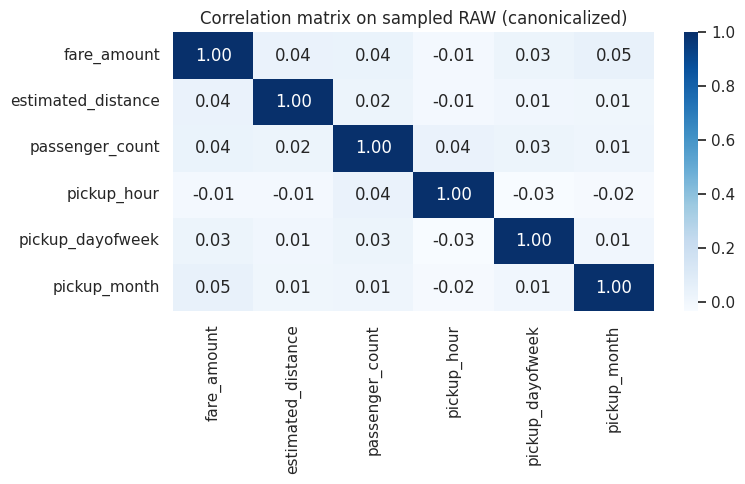

In [9]:
corr_cols = ['fare_amount', DISTANCE_COLUMN, 'passenger_count', 'pickup_hour', 'pickup_dayofweek', 'pickup_month']
corr_df = eda_df[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(8, 5))
sns.heatmap(corr_df, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation matrix on sampled RAW (canonicalized)')
plt.tight_layout()


In [10]:
outlier_view = eda_df[['fare_amount', DISTANCE_COLUMN]].describe(percentiles=[0.95, 0.99, 0.995, 0.999]).T
outlier_view


,count,mean,std,min,50%,95%,99%,99.5%,99.9%,max
fare_amount,10000.0,17.878588,16.987461,-119.6,13.5,49.2000,75.1000,90.0000,150.00400,288.60
estimated_distance,10000.0,3.873869,79.810450,0.0,1.8,10.6705,18.6802,20.7002,32.07068,7974.43


## Conclusiones e interpretacion

- La muestra balanceada usada en este EDA quedo efectivamente repartida en `5000` filas `yellow` y `5000` filas `green`, lo que evita sesgo descriptivo por volumen y deja comparables ambas flotas desde RAW.
- Aun antes de limpiar, la data muestra defectos estructurales claros: `306` filas con `fare_amount <= 0`, `395` con `estimated_distance <= 0`, `103` con `passenger_count` fuera del rango esperado y una brecha amplia entre las `10000` filas exploradas y las `8058` que ya pasan las reglas candidatas de calidad.
- La presencia de leakage es explicita en RAW: aparecen `payment_type`, `tip_amount`, `tolls_amount`, `extra`, `mta_tax`, `improvement_surcharge`, `congestion_surcharge`, `airport_fee` y `total_amount`. Esto confirma que la OBT final debe excluirlas de forma estricta.
- El campo `airport_fee` presenta `60.83%` de nulos en la muestra combinada, lo cual es consistente con mezclar flotas y confirma que no debe tratarse como feature base. Del mismo modo, `passenger_count`, `ratecode_id` y `congestion_surcharge` muestran faltantes suficientes como para exigir reglas explicitas de limpieza o tolerancia en capas diagnosticas.
- Los percentiles confirman colas pesadas y valores extremos en `fare_amount` y, sobre todo, en `estimated_distance` (`max = 7974.43`). Esos extremos no deben eliminarse por reflejo en EDA, pero si justifican filtros estructurales minimos en `STAGING` y vigilancia especifica en `02_data_cleaning.ipynb`.
- El siguiente notebook debe probar formalmente las reglas ya sugeridas aqui: `pickup_datetime` y `dropoff_datetime` validos, `dropoff > pickup`, `fare_amount > 0`, `estimated_distance > 0`, `passenger_count` en rango y preservacion de `trip_type` como feature de segmentacion entre flotas.
- Este EDA deja una conclusion metodologica clara: el modelado no debe salir de RAW directo. Primero se audita, luego se justifican reglas de calidad, y recien despues se materializa `STAGING` y la OBT final.
